--- Starting Difference Analysis: 18 Scenarios vs LSTM ---
Reading Scenarios from: E:\Projetos\ABMS-WP\resultados\consumo_previsto_todos_cenarios.csv
Reading LSTM from: E:\Projetos\ABMS-WP\modelos IA\previsoes_futuras_2025_2035.csv
Chart saved to: E:\Projetos\ABMS-WP\figuras\diferenca_cenarios_vs_lstm.pdf


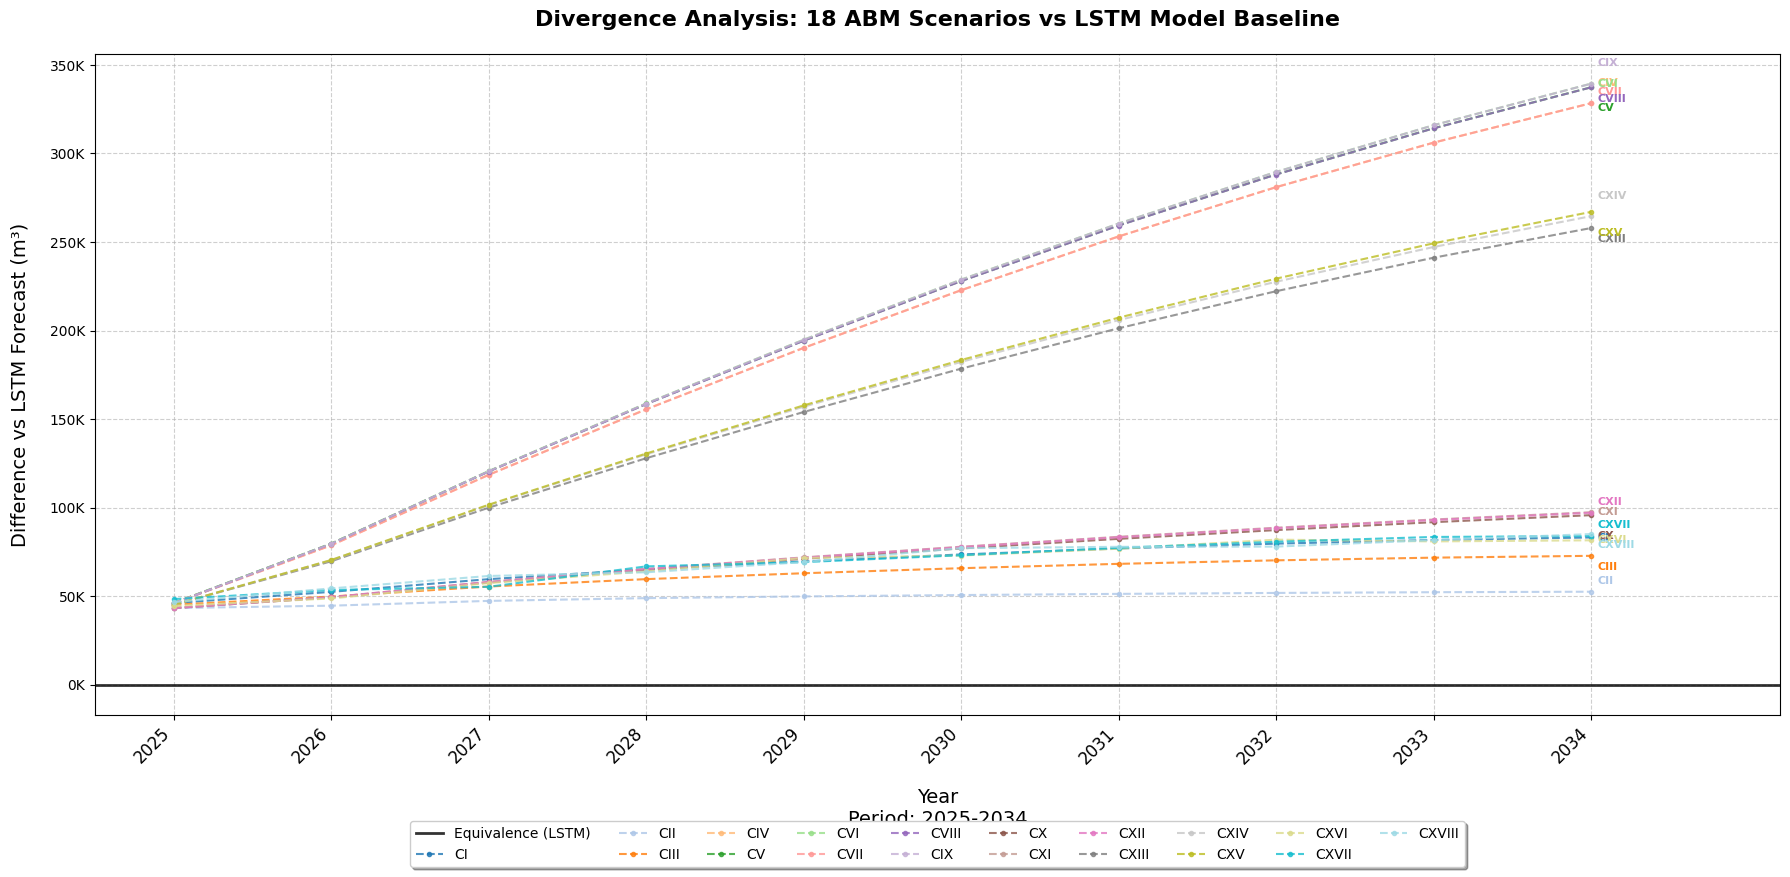

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configuration and Paths
# ==========================================

# Define the base project directory
# Uncomment the appropriate path for your environment
BASE_PATH = 'E:\\Projetos\\ABM-WP' # Currently active path

# Input Files
SCENARIO_FILE = 'consumo_previsto_todos_cenarios.csv'
LSTM_FILE = 'previsoes_futuras_2025_2035.csv'

# Output File
OUTPUT_FILENAME = 'diferenca_cenarios_vs_lstm.pdf'

# Directory Setup
INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')

def sum_yearly(df, date_col, value_cols):
    """ Helper to aggregate monthly data to annual sums """
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()

def main():
    print("--- Starting Difference Analysis: 18 Scenarios vs LSTM ---")

    # ==========================================
    # 2. Load Data
    # ==========================================
    
    # A. Load Scenarios
    # Try primary path
    path_scenarios = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scenarios):
        # Try secondary path
        path_scenarios = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)
    
    # Fallback for VM execution (current dir)
    if not os.path.exists(path_scenarios):
        path_scenarios = SCENARIO_FILE

    print(f"Reading Scenarios from: {path_scenarios}")
    if os.path.exists(path_scenarios):
        df_scenarios = pd.read_csv(path_scenarios, sep=';', decimal=',')
    else:
        print(f"Error: Scenarios file not found: {path_scenarios}")
        return
    
    # Date Construction
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + 
                                            df_scenarios['Mes'].astype(str) + '-01')
    elif 'Mes_Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Mes_Ano'], format='%m/%Y')
        
    scenario_cols = [c for c in df_scenarios.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date']]
    df_scenarios = df_scenarios[df_scenarios['Date'] <= pd.to_datetime('2034-12-31')]

    # B. Load LSTM
    path_lstm = os.path.join(INPUT_DIR_MODELS, LSTM_FILE)
    # Fallback for VM
    if not os.path.exists(path_lstm):
        path_lstm = LSTM_FILE
        
    print(f"Reading LSTM from: {path_lstm}")
    if os.path.exists(path_lstm):
        df_lstm = pd.read_csv(path_lstm, parse_dates=['Data'])
        df_lstm = df_lstm.rename(columns={'Data': 'Date', 'Valor Previsto': 'LSTM'})
        df_lstm = df_lstm[df_lstm['Date'] <= pd.to_datetime('2034-12-31')]
    else:
        print(f"Error: LSTM file not found: {path_lstm}")
        return

    # ==========================================
    # 3. Calculation
    # ==========================================
    
    # Merge
    df_combined = pd.merge(df_scenarios, df_lstm[['Date', 'LSTM']], on='Date', how='left')
    
    # Annual Aggregation
    all_numeric = scenario_cols + ['LSTM']
    df_annual = sum_yearly(df_combined, 'Date', all_numeric)
    
    # Calculate Differences (Scenario - LSTM)
    diff_cols = []
    for col in scenario_cols:
        diff_col_name = f"Diff_{col}"
        df_annual[diff_col_name] = df_annual[col] - df_annual['LSTM']
        diff_cols.append(diff_col_name)

    scenario_period = f"{df_annual['Year'].min()}-{df_annual['Year'].max()}"

    # ==========================================
    # 4. Plotting
    # ==========================================
    
    plt.figure(figsize=(18, 9))
    ax = plt.gca()
    
    # Reference line at y=0 (Equivalence point)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=2, alpha=0.8, label='Equivalence (LSTM)')

    # Color map
    colors = plt.cm.tab20(np.linspace(0, 1, len(diff_cols)))
    
    # Offset cycle for direct labels to avoid overlap
    offset_cycle = [(5, 0), (5, 8), (5, -8), (5, 15), (5, -15)]

    for idx, col in enumerate(diff_cols):
        # Extract original ID from "Diff_CIV_..." -> "CIV"
        original_name = col.replace("Diff_", "")
        scenario_id = original_name.split('_')[0]
        
        # Plot difference line
        ax.plot(df_annual['Year'], df_annual[col],
                color=colors[idx],
                linestyle='--',
                linewidth=1.5,
                marker='.',
                markersize=6,
                alpha=0.8,
                label=scenario_id)
        
        # Direct Labeling at the end
        last_year = df_annual['Year'].iloc[-1]
        last_val = df_annual[col].iloc[-1]
        curr_offset = offset_cycle[idx % len(offset_cycle)]
        
        if not pd.isna(last_val):
             ax.annotate(scenario_id, 
                        (last_year, last_val), 
                        xytext=curr_offset, 
                        textcoords="offset points", 
                        ha='left', va='center',
                        fontsize=8, color=colors[idx], fontweight='bold')

    # ==========================================
    # 5. Formatting
    # ==========================================
    
    # X-Axis
    ax.set_xticks(df_annual['Year'])
    ax.set_xticklabels(df_annual['Year'], rotation=45, ha='right', fontsize=12)
    
    # Y-Axis (K format)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
    
    # Limits (Extra space for labels)
    ax.set_xlim(df_annual['Year'].min() - 0.5, df_annual['Year'].max() + 1.2)
    
    # Labels
    ax.set_xlabel(f"Year\nPeriod: {scenario_period}", fontsize=14, labelpad=15)
    ax.set_ylabel('Difference vs LSTM Forecast (m³)', fontsize=14, labelpad=15)
    plt.title('Divergence Analysis: 18 ABM Scenarios vs LSTM Model Baseline', 
              fontsize=16, pad=20, fontweight='bold')
    
    plt.grid(True, linestyle='--', alpha=0.6)

    # Legend at footer
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
               ncol=10, fancybox=True, shadow=True, fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)

    # ==========================================
    # 6. Saving
    # ==========================================
    
    # Save Path Construction
    if os.path.exists(OUTPUT_DIR):
        full_output_path = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
    else:
        # Fallback for VM
        full_output_path = OUTPUT_FILENAME
        
    plt.savefig(full_output_path, format='pdf', bbox_inches='tight')
    
    print(f"Chart saved to: {full_output_path}")
    plt.show()

if __name__ == "__main__":
    main()